**The Concept of Love in Russian and Spanish Literature**

This project studies how the concept of love is linguistically constructed in 19th century, Russian and Spanish romantic literature using Word2Vec distributional semantic models.

**Hypothesis:** In Russian literature, love is more closely associated with the soul, longing and suffering, while in Spanish literature it tends to cluster around passion, desire and physical emotion.

**Corpus:**
- Russian (15 novels): Ivan Turgenev, Lev Tolstoy, Fyodor Dostoevsky, Alexander Kuprin, Ivan Goncharov, Ivan Bunin, Anton Chekhov
- Spanish (15 novels): Benito Pérez Galdós, Juan Valera, Gustavo Adolfo Bécquer, Leopoldo Alas "Clarín", Emilia Pardo Bazán, Vicente Blasco Ibáñez

**Methods:**
I lemmatized the texts using pymorphy3 for Russian and spaCy for Spanish. Then I trained Word2Vec models with gensim to analyze semantic relationships between words. To visualize I applied t-SNE dimensionality reduction and I used cosine similarity to compare the meanings and associations of key terms across the corpora.

In [3]:
!pip install pymorphy3 -q
!pip install spacy -q
!python -m spacy download es_core_news_sm -q
!pip install pymorphy3 gensim spacy plotly -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 120.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.9 MB/s eta 0:00:00


In [4]:
import os, re, zipfile
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pymorphy3
import spacy
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
nltk.download('stopwords', quiet=True)

True

In [7]:
with zipfile.ZipFile('/content/corpus.zip', 'r') as z:
    z.extractall('/content/')

def load(path):
  l = []
  for f in os.listdir(path):
    if f.endswith('.txt'):
      with open(f"{path}/{f}", 'r', encoding='utf-8') as file:
        l.append(file.read())
  return " ".join(l)

ru_corp = load('/content/corpus/RU')
sp_corp = load('/content/corpus/SP')

In [8]:
def clean(texto):
  texto = texto.lower()
  texto = re.sub(r'[^\w\s]', '', texto)
  return texto.split()

ru_tok = clean(ru_corp)
sp_tok = clean(sp_corp)

In [9]:
morph = pymorphy3.MorphAnalyzer()
nlp = spacy.load('es_core_news_sm')
nlp.max_length = 15000000
def lem_ru(tok, cs=50000):
  res = []
  for i in range(0, len(tok), cs):
    res.extend([morph.parse(w)[0].normal_form for w in tok[i:i+cs]])
  return res

def lem_es(tok, cs=50000):
  res = []
  for i in range(0, len(tok), cs):
    doc = nlp(' '.join(tok[i:i+cs]))
    res.extend([t.lemma_ for t in doc])
  return res

ru_lem = lem_ru(ru_tok)
sp_lem = lem_es(sp_tok)

In [14]:
sw_ru = set(stopwords.words('russian'))
sw_ru.update(['который', 'это', 'наш', 'свой', 'быть', 'мочь', 'весь', 'всё', 'год', 'ещё', 'кить',
              'сказать', 'говорить', 'стать', 'знать', 'левин', 'обломов', 'барин', 'вронский',
              'катюша', 'нехлюдов', 'маслов', 'председатель', 'тётушка', 'подсудимый'])

sw_es = set(stopwords.words('spanish'))
sw_es.update(['ser', 'tener', 'señor', 'gran', 'grande', 'hacer', 'decir', 'haber', 'poder',
              'aquí', 'así', 'bien', 'cosa', 'dio', 'nela', 'tío', 'casa', 'calle', 'parecer', 'poner'])

ru_w = [w for w in ru_lem if w not in sw_ru and w.isalnum() and len(w) > 2]
sp_w = [w for w in sp_lem if w not in sw_es and w.isalnum() and len(w) > 2]

ru_m = Word2Vec([ru_w], vector_size=100, window=5, min_count=2, epochs=10)
sp_m = Word2Vec([sp_w], vector_size=100, window=5, min_count=2, epochs=10)

## Results

### Most similar words to key concepts

The following table shows the top 5 semantically closest words to key love-related concepts in each language as learned by the Word2Vec model.

In [15]:
kw_ru = ['любовь', 'сердце', 'душа', 'боль', 'тоска']
kw_es = ['amor', 'corazón', 'alma', 'dolor', 'pasión']

for w in kw_ru:
  if w in ru_m.wv:
    print(f"\n{w}:", ru_m.wv.most_similar(w, topn=5))

for w in kw_es:
  if w in sp_m.wv:
    print(f"\n{w}:", sp_m.wv.most_similar(w, topn=5))


любовь: [('выйти', 0.47275179624557495), ('очень', 0.4569862186908722), ('деньга', 0.45172616839408875), ('делать', 0.4325048625469208), ('женщина', 0.4262751638889313)]

сердце: [('мамаша', 0.378410667181015), ('гнёздышко', 0.3643401861190796), ('будущность', 0.35426586866378784), ('тургенев', 0.3446669578552246), ('свистать', 0.33380258083343506)]

душа: [('белый', 0.44918832182884216), ('товарищ', 0.44559523463249207), ('смельков', 0.44534969329833984), ('глаз', 0.4451921880245209), ('человек', 0.4391629695892334)]

боль: [('простенький', 0.3945319652557373), ('спор', 0.3437063694000244), ('краса', 0.34287622570991516), ('теряться', 0.3422267735004425), ('походить', 0.34144800901412964)]

тоска: [('elle', 0.43690019845962524), ('вестовый', 0.33796101808547974), ('луженовский', 0.3260759711265564), ('старуха', 0.3247941732406616), ('папироска', 0.32478004693984985)]

amor: [('felicísima', 0.4203897714614868), ('menester', 0.36975666880607605), ('abraham', 0.35085663199424744), ('pri

### Semantic space visualization (t-SNE)

The following plots show the position of love-related words in the semantic space after reducing the embeddings to two dimensions with t-SNE. Words that are closer together tend to appear in similar contexts and have stronger semantic associations.

In [16]:
pal_ru = ['любовь', 'сердце', 'душа', 'боль', 'тоска', 'нежность', 'страсть', 'разлука', 'измена', 'счастье']
pal_es = ['amor', 'corazón', 'alma', 'dolor', 'pasión', 'ternura', 'separación', 'felicidad', 'deseo', 'tristeza']

def tsne_interactive(m, words, title):
  valid = [w for w in words if w in m.wv]
  vecs = np.array([m.wv[w] for w in valid])
  coords = TSNE(n_components=2, random_state=42, perplexity=min(5, len(valid)-1)).fit_transform(vecs)
  fig = go.Figure()
  fig.add_trace(go.Scatter(
      x=coords[:, 0], y=coords[:, 1],
      mode='markers+text', text=valid, textposition='top center',
      marker=dict(size=8, opacity=0.7)))
  fig.update_layout(title=title, template='plotly_white')
  fig.show()

tsne_interactive(ru_m, pal_ru, 'Semantic space - Love in Russian literature')
tsne_interactive(sp_m, pal_es, 'Semantic space - Love in Spanish literature')

### Cosine similarity comparison

This chart compares the cosine similarity of equivalent love-related words in russian and spanish with respect to their core concept (любовь/ amor). higher values indicate stronger semantic association.

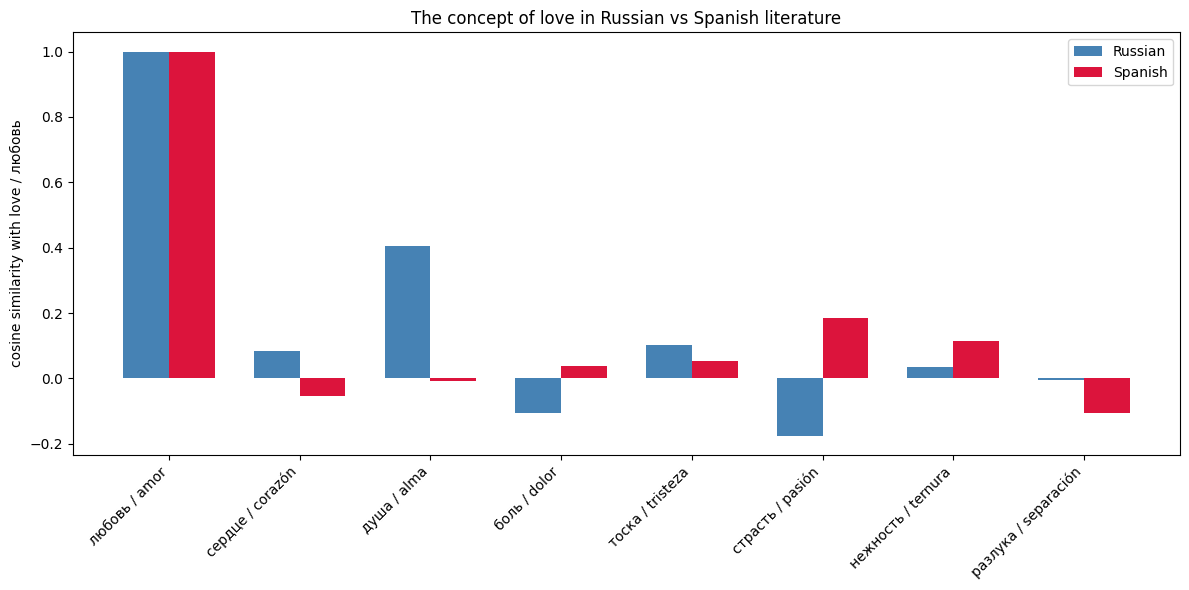

In [17]:
pairs = [('любовь', 'amor'), ('сердце', 'corazón'), ('душа', 'alma'), ('боль', 'dolor'), ('тоска', 'tristeza'), ('страсть', 'pasión'), ('нежность', 'ternura'), ('разлука', 'separación')]

sr, se, labs = [], [], []
for r, e in pairs:
  if r in ru_m.wv and e in sp_m.wv:
    sr.append(ru_m.wv.similarity('любовь', r))
    se.append(sp_m.wv.similarity('amor', e))
    labs.append(f"{r} / {e}")

x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.175, sr, 0.35, label='Russian', color='steelblue')
ax.bar(x + 0.175, se, 0.35, label='Spanish', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(labs, rotation=45, ha='right')
ax.set_ylabel('cosine similarity with love / любовь')
ax.set_title('The concept of love in Russian vs Spanish literature')
ax.legend()
plt.tight_layout()
plt.savefig('comparison_love.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussion

One of the first things I noticed in the T-SNE plots is how _душа_ sits very close to _любовь_ in the Russian space. Love in Russian romantic literature seems deeply tied to the inner and spiritual world, almost inseparable from the soul. It's also telling that _тоска_ and _боль_ form their own cluster, as if suffering were part of the definition of love itself not just a consequence.

In Spanish, _amor_ (love) and _pasión_ cluster together, which means with my hypothesis. Love here feels more outward and emotionally intense. _Corazón_ (heart) appears more isolated, which I didn't expect.

In the cosine similarity chart, Russian shows a much stronger link between _любовь_ and _душа_ than Spanish does between _amor_ (love) and _alma_ (soul). Meanwhile, _pasión_ scores higher in Spanish consistent with what the t-SNE suggests.

## Limitations

The Spanish corpus had some noise from mixed-language Gutenberg texts, which likely affected my model. The corpus is also small for Word2Vec, so results for less frequent words should be taken with caution.

## Further research
A larger and cleaner corpus would be the obvious next step. It would also be interesting to look at how these associations shift across different literary periods , whether love in early 19th century Russian literature "feels" the same as in late 19th century texts for example.